# 4A - Ciclo ENSO em 4 fases: rotulo semanal e cronologia de cada evento

**Pergunta especifica.** Em que fase do ciclo ENSO cada semana do projeto esta? A etapa 4A transforma a serie mensal ONI local em uma tabela semanal auditavel: cada domingo recebe `tipo` (`el_nino`, `la_nina` ou `neutro`), `fase` (`genese`, `crescimento`, `pico`, `decaimento` ou `neutro`), `event_id`, classe do evento e semanas relativas ao onset/pico.

**Como as fases sao definidas.** Eventos seguem o criterio ONI local simetrico: media movel de 3 meses da SSTA Nino 3.4 >= +0,5 C (El Nino) ou <= -0,5 C (La Nina) por pelo menos 5 estacoes moveis sobrepostas. Dentro de cada evento: **pico** = plateau com |ONI| >= 90% do |ONI| maximo; **crescimento** = onset ate inicio do plateau; **decaimento** = fim do plateau ate fim do evento; **genese** = 26 semanas antes do onset, sem sobrescrever outro evento.

**Por que isso importa para a Fase 4.** O Brasil nao responde a um El Nino abstrato: responde ao sinal em momentos diferentes do ciclo. O 4A fornece a cronologia que condiciona 4B-4D.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase4_utils as u

oni = u.load_oni_monthly()
ev = u.enso_events(oni)
u.save_table(ev, 'phase4A_eventos_enso.csv', index=False)
print(f"Eventos: {int((ev.tipo=='el_nino').sum())} El Nino, {int((ev.tipo=='la_nina').sum())} La Nina")
print(ev[['event_id','tipo','classe','onset','pico','fim','duracao_estacoes','oni_pico_c']].to_string(index=False))

[tabela] data\processed\parquet\statistics\phase4A_eventos_enso.csv
Eventos: 12 El Nino, 11 La Nina
         event_id    tipo      classe      onset       pico        fim  duracao_estacoes  oni_pico_c
el_nino_1982_1983 el_nino muito_forte 1982-07-01 1983-01-01 1983-05-31                11       2.120
la_nina_1983_1984 la_nina    moderada 1983-09-01 1983-11-01 1984-02-29                 6      -1.210
la_nina_1984_1986 la_nina    moderada 1984-04-01 1984-12-01 1986-04-30                25      -1.392
el_nino_1986_1988 el_nino    moderado 1986-10-01 1987-08-01 1988-01-31                16       1.211
la_nina_1988_1989 la_nina muito_forte 1988-04-01 1988-11-01 1989-10-31                19      -2.125
el_nino_1991_1992 el_nino       forte 1991-09-01 1992-01-01 1992-06-30                10       1.625
el_nino_1994_1995 el_nino       fraco 1994-10-01 1994-12-01 1995-02-28                 5       0.968
la_nina_1995_1996 la_nina       fraca 1995-09-01 1995-11-01 1996-04-30                 8    

In [2]:
w = u.load_pacific_weekly()
fases = u.enso_phase_weekly(oni, ev, w.index)

# Enriquecimento cronologico: semana relativa ao onset e ao pico de cada evento.
fases['fase_ordem'] = fases['fase'].map({f: i+1 for i, f in enumerate(u.FASE_ORDER)}).fillna(0).astype(int)
fases['classe'] = ''
fases['oni_pico_c'] = np.nan
fases['onset'] = pd.NaT
fases['pico'] = pd.NaT
fases['fim'] = pd.NaT
fases['semana_rel_onset'] = np.nan
fases['semana_rel_pico'] = np.nan
for _, e in ev.iterrows():
    m = fases['event_id'].eq(e.event_id)
    if not m.any():
        continue
    idx = fases.index[m]
    fases.loc[m, 'classe'] = e.classe
    fases.loc[m, 'oni_pico_c'] = e.oni_pico_c
    fases.loc[m, 'onset'] = e.onset
    fases.loc[m, 'pico'] = e.pico
    fases.loc[m, 'fim'] = e.fim
    fases.loc[m, 'semana_rel_onset'] = ((idx - pd.Timestamp(e.onset)).days / 7).astype(int)
    fases.loc[m, 'semana_rel_pico'] = ((idx - pd.Timestamp(e.pico)).days / 7).astype(int)

u.save_table(fases, 'phase4A_fases_semanais.csv')
resumo = (fases.groupby(['tipo','fase']).size().rename('semanas').reset_index())
resumo['fracao_%'] = (100*resumo['semanas']/len(fases)).round(1)
u.save_table(resumo, 'phase4A_fases_resumo.csv', index=False)
print(resumo.to_string(index=False))

# Cronologia por evento e fase: inicio, fim e duracao em semanas.
cron_rows = []
for _, e in ev.iterrows():
    sub_event = fases[fases['event_id'] == e.event_id]
    row = {'event_id': e.event_id, 'tipo': e.tipo, 'classe': e.classe, 'oni_pico_c': e.oni_pico_c}
    for fase in u.FASE_ORDER:
        sf = sub_event[sub_event['fase'].eq(fase)]
        row[f'{fase}_inicio'] = sf.index.min().date() if len(sf) else ''
        row[f'{fase}_fim'] = sf.index.max().date() if len(sf) else ''
        row[f'{fase}_sem'] = int(len(sf))
    cron_rows.append(row)
cron = pd.DataFrame(cron_rows)
u.save_table(cron, 'phase4A_evento_fases_cronologia.csv', index=False)

cols = [f'{f}_sem' for f in u.FASE_ORDER]
dur = cron[['event_id','tipo','classe','oni_pico_c'] + cols].copy()
u.save_table(dur, 'phase4A_duracao_fases_por_evento.csv', index=False)
print(cron.to_string(index=False))

[tabela] data\processed\parquet\statistics\phase4A_fases_semanais.csv
[tabela] data\processed\parquet\statistics\phase4A_fases_resumo.csv
   tipo        fase  semanas  fracao_%
el_nino crescimento      236       9.9
el_nino  decaimento      128       5.4
el_nino      genese      295      12.4
el_nino        pico      162       6.8
la_nina crescimento      162       6.8
la_nina  decaimento      272      11.5
la_nina      genese      183       7.7
la_nina        pico      217       9.1
 neutro      neutro      720      30.3


[tabela] data\processed\parquet\statistics\phase4A_evento_fases_cronologia.csv
[tabela] data\processed\parquet\statistics\phase4A_duracao_fases_por_evento.csv
         event_id    tipo      classe  oni_pico_c genese_inicio genese_fim  genese_sem crescimento_inicio crescimento_fim  crescimento_sem pico_inicio   pico_fim  pico_sem decaimento_inicio decaimento_fim  decaimento_sem
el_nino_1982_1983 el_nino muito_forte       2.120    1982-01-03 1982-06-27          26         1982-07-04      1982-10-31               18  1982-11-07 1983-01-30        13        1983-02-06     1983-05-29              17
la_nina_1983_1984 la_nina    moderada      -1.210    1983-06-05 1983-08-28          13         1983-09-04      1983-10-30                9  1983-11-06 1983-12-25         8        1984-01-01     1984-02-26               9
la_nina_1984_1986 la_nina    moderada      -1.392    1984-03-04 1984-03-25           4         1984-04-01      1984-11-25               35  1984-12-02 1985-01-27         9       

[figura] data\processed\figures\fase4\Fig_4A1_ciclo_enso_fases.png


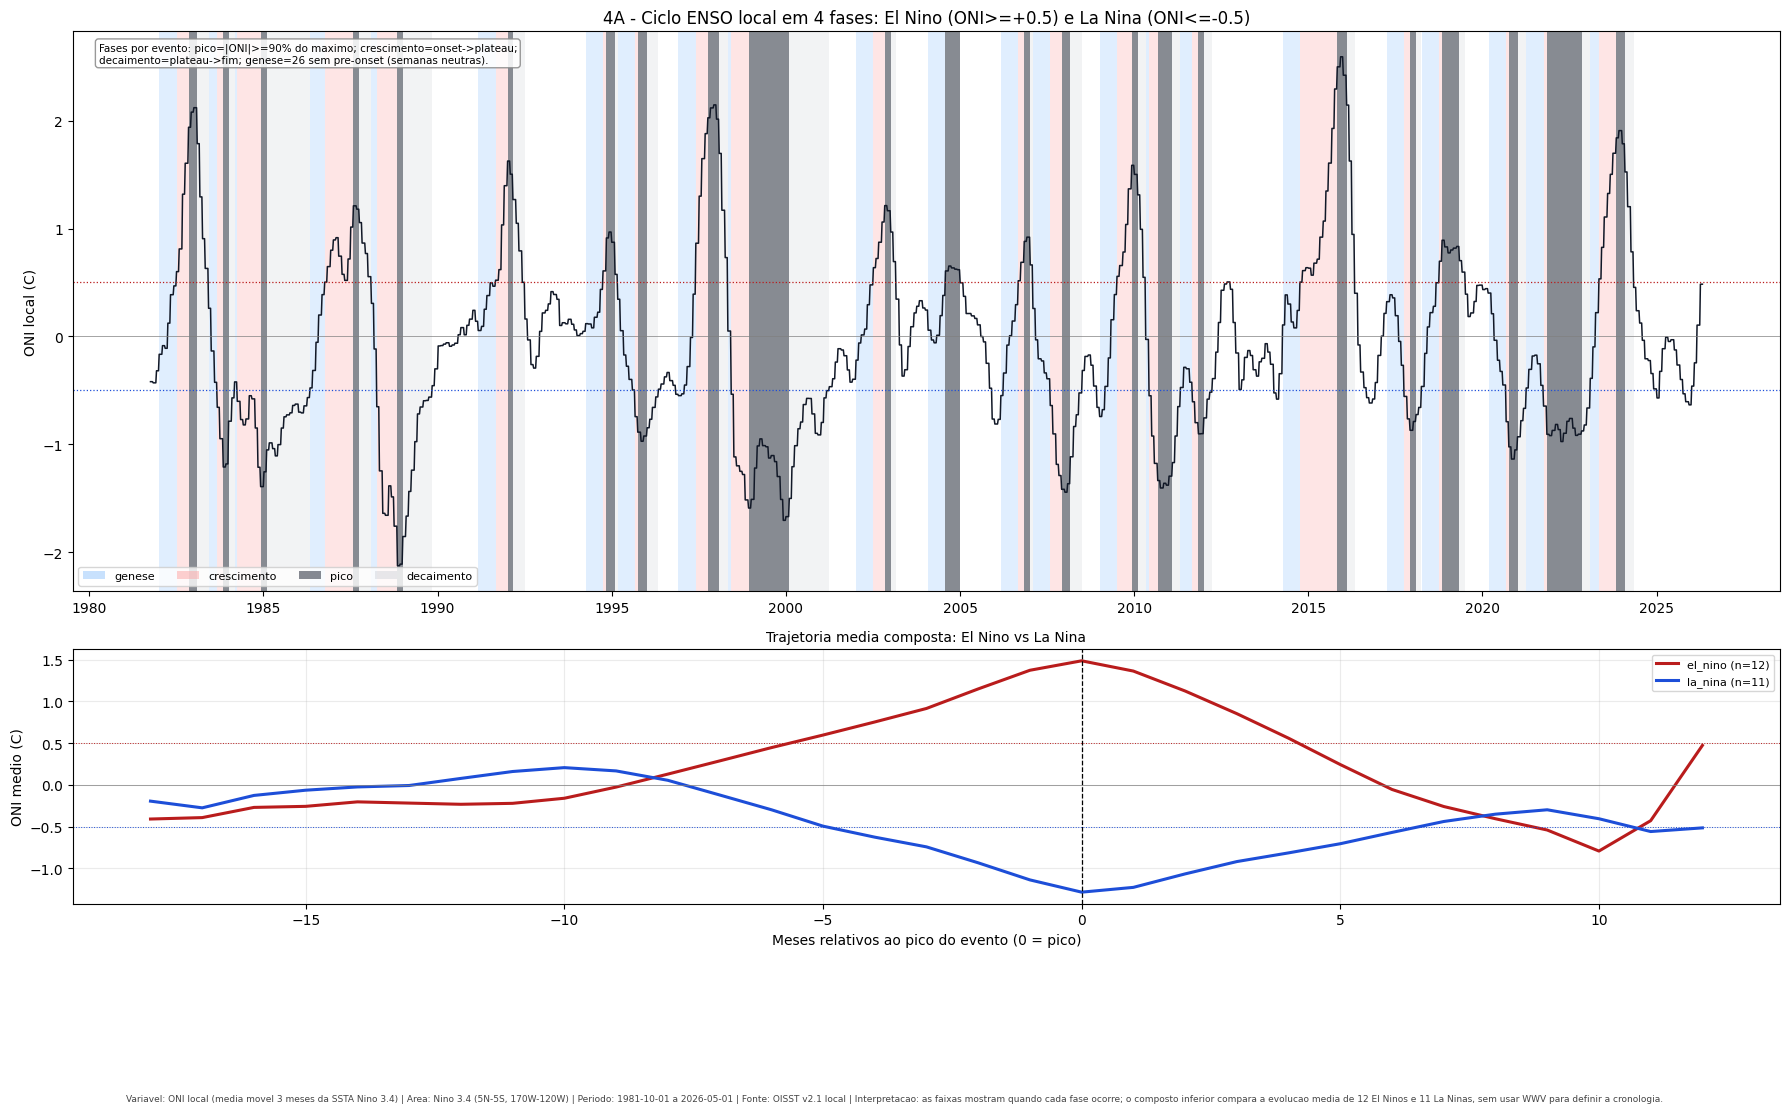

In [3]:
oni_w = oni.reindex(pd.date_range(oni.index.min(), oni.index.max(), freq='W-SUN'), method='ffill')
fig, axes = plt.subplots(2, 1, figsize=(18, 11), gridspec_kw={'height_ratios':[2.2, 1]})
ax = axes[0]
for i in range(len(fases)-1):
    f, tp = fases['fase'].iloc[i], fases['tipo'].iloc[i]
    if f == 'neutro':
        continue
    cor = u.FASE_CORES[f]
    ax.axvspan(fases.index[i], fases.index[i+1], color=cor, alpha=.28 if f!='pico' else .5, lw=0)
ax.plot(oni_w.index, oni_w.values, color='#111827', lw=1.1)
ax.axhline(0.5, color='#b91c1c', ls=':', lw=.9); ax.axhline(-0.5, color='#1d4ed8', ls=':', lw=.9)
ax.axhline(0, color='0.5', lw=.5)
ax.set_ylabel('ONI local (C)')
ax.set_title('4A - Ciclo ENSO local em 4 fases: El Nino (ONI>=+0.5) e La Nina (ONI<=-0.5)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(fc=u.FASE_CORES[f], alpha=.5, label=f) for f in u.FASE_ORDER], fontsize=8, ncol=4, loc='lower left')
u.add_note(ax, 'Fases por evento: pico=|ONI|>=90% do maximo; crescimento=onset->plateau;\ndecaimento=plateau->fim; genese=26 sem pre-onset (semanas neutras).', loc='upper left')
ax2 = axes[1]
for j, tipo in enumerate(['el_nino','la_nina']):
    sub = ev[ev.tipo==tipo]
    comps = []
    for _, e in sub.iterrows():
        seg = oni.loc[pd.to_datetime(e.onset)-pd.DateOffset(months=12):pd.to_datetime(e.fim)+pd.DateOffset(months=6)]
        rel = ((seg.index - pd.to_datetime(e.pico)).days/30.44).round().astype(int)
        comps.append(pd.Series(seg.values, index=rel).groupby(level=0).mean().reindex(range(-18,13)))
    m = pd.DataFrame(comps).mean()
    cor = '#b91c1c' if tipo=='el_nino' else '#1d4ed8'
    ax2.plot(m.index, m.values, color=cor, lw=2.2, label=f"{tipo} (n={len(sub)})")
ax2.axvline(0, color='k', ls='--', lw=.9); ax2.axhline(0, color='0.5', lw=.5)
ax2.axhline(0.5, color='#b91c1c', ls=':', lw=.7); ax2.axhline(-0.5, color='#1d4ed8', ls=':', lw=.7)
ax2.set_xlabel('Meses relativos ao pico do evento (0 = pico)')
ax2.set_ylabel('ONI medio (C)')
ax2.legend(fontsize=8); ax2.grid(alpha=.25)
ax2.set_title('Trajetoria media composta: El Nino vs La Nina', fontsize=10)
fig.tight_layout(rect=(0, .08, 1, .96))
u.stamp_caption(fig, variavel='ONI local (media movel 3 meses da SSTA Nino 3.4)', area='Nino 3.4 (5N-5S, 170W-120W)', periodo=f'{oni.dropna().index.min().date()} a {oni.dropna().index.max().date()}', fonte='OISST v2.1 local', extra=f'Interpretacao: as faixas mostram quando cada fase ocorre; o composto inferior compara a evolucao media de {int((ev.tipo=="el_nino").sum())} El Ninos e {int((ev.tipo=="la_nina").sum())} La Ninas, sem usar WWV para definir a cronologia.')
u.save_fig(fig, 'Fig_4A1_ciclo_enso_fases.png')
plt.show()

[figura] data\processed\figures\fase4\Fig_4A2_duracao_distribuicao_fases.png


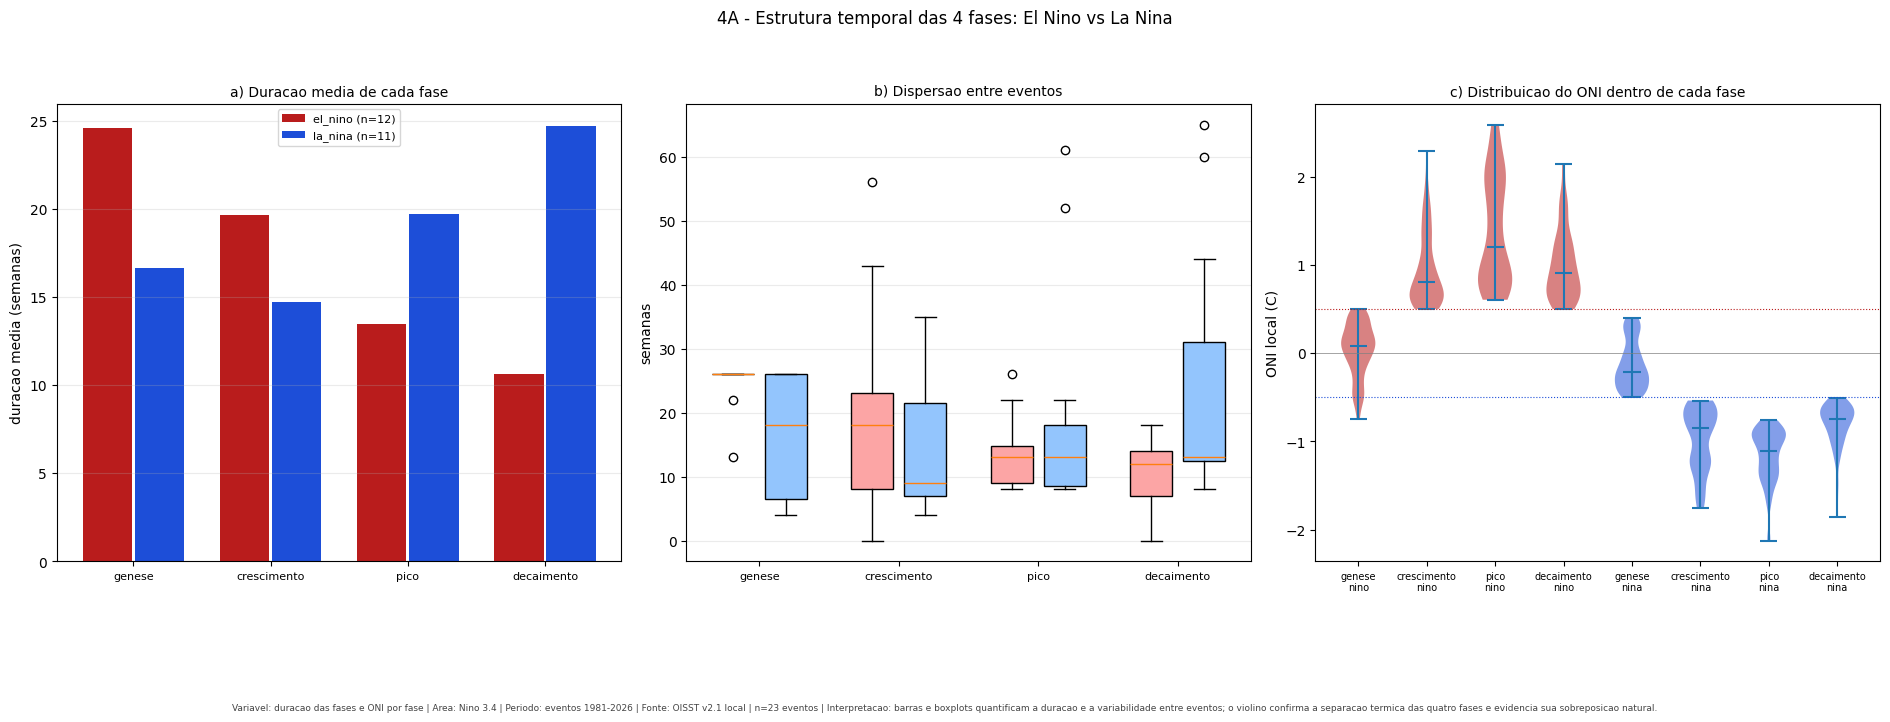

In [4]:
# Avaliacao expandida: quanto dura cada fase, por tipo e classe; e o ONI dentro de cada fase
cols = [f'{f}_sem' for f in u.FASE_ORDER]
fig, axes = plt.subplots(1, 3, figsize=(19, 6.8))
med = dur.groupby('tipo')[cols].mean()
xx = np.arange(len(u.FASE_ORDER))
for k, (tipo, cor) in enumerate([('el_nino','#b91c1c'), ('la_nina','#1d4ed8')]):
    axes[0].bar(xx + (k-.5)*.38, med.loc[tipo, cols], width=.36, color=cor, label=f'{tipo} (n={int((dur.tipo==tipo).sum())})')
axes[0].set_xticks(xx); axes[0].set_xticklabels(u.FASE_ORDER, fontsize=8)
axes[0].set_ylabel('duracao media (semanas)')
axes[0].set_title('a) Duracao media de cada fase', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=.25)

for k, tipo in enumerate(['el_nino','la_nina']):
    sub = dur[dur.tipo==tipo]
    bp = axes[1].boxplot([sub[c] for c in cols], positions=xx + (k-.5)*.38, widths=.3, patch_artist=True, manage_ticks=False)
    for b in bp['boxes']:
        b.set_facecolor('#fca5a5' if tipo=='el_nino' else '#93c5fd')
axes[1].set_xticks(xx); axes[1].set_xticklabels(u.FASE_ORDER, fontsize=8)
axes[1].set_title('b) Dispersao entre eventos', fontsize=10)
axes[1].set_ylabel('semanas'); axes[1].grid(axis='y', alpha=.25)

fases_on = fases.join(oni_w.rename('oni'))
dados, labels, cores = [], [], []
for tipo, cor in [('el_nino','#b91c1c'), ('la_nina','#1d4ed8')]:
    for f in u.FASE_ORDER:
        v = fases_on.loc[(fases_on.tipo==tipo) & (fases_on.fase==f), 'oni'].dropna()
        dados.append(v); labels.append(f'{f}\n{tipo.split("_")[1]}'); cores.append(cor)
vp = axes[2].violinplot(dados, showmedians=True)
for body, cor in zip(vp['bodies'], cores):
    body.set_facecolor(cor); body.set_alpha(.55)
axes[2].axhline(0.5, color='#b91c1c', ls=':', lw=.8); axes[2].axhline(-0.5, color='#1d4ed8', ls=':', lw=.8)
axes[2].axhline(0, color='0.5', lw=.5)
axes[2].set_xticks(range(1, len(labels)+1)); axes[2].set_xticklabels(labels, fontsize=7)
axes[2].set_ylabel('ONI local (C)')
axes[2].set_title('c) Distribuicao do ONI dentro de cada fase', fontsize=10)
fig.suptitle('4A - Estrutura temporal das 4 fases: El Nino vs La Nina')
fig.tight_layout(rect=(0, .10, 1, .94))
u.stamp_caption(fig, variavel='duracao das fases e ONI por fase', area='Nino 3.4', periodo='eventos 1981-2026', fonte='OISST v2.1 local', n=f"{len(ev)} eventos", extra='Interpretacao: barras e boxplots quantificam a duracao e a variabilidade entre eventos; o violino confirma a separacao termica das quatro fases e evidencia sua sobreposicao natural.')
u.save_fig(fig, 'Fig_4A2_duracao_distribuicao_fases.png')
plt.show()

[figura] data\processed\figures\fase4\Fig_4A3_plano_cronologico_oni_tendencia.png


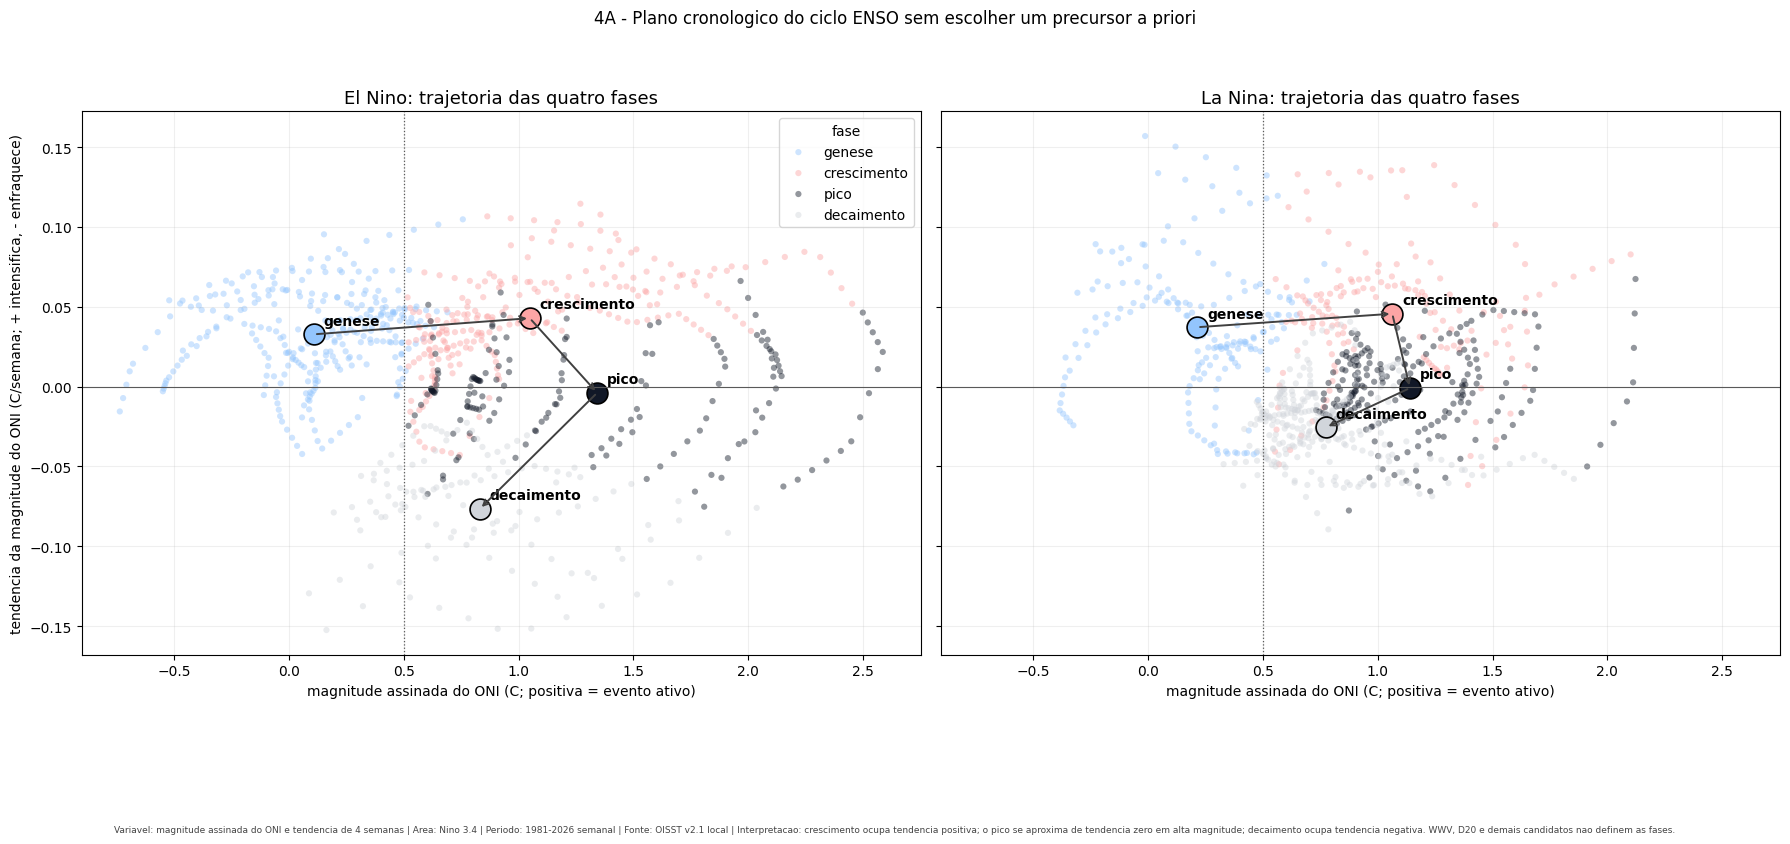

In [5]:
# Plano cronologico sem privilegiar um precursor: magnitude assinada do ONI x sua tendencia.
weeks = fases.index
oni_phase = (oni.reindex(oni.index.union(weeks)).sort_index()
             .interpolate(method='time').reindex(weeks))
oni_tendency = oni_phase.diff(4) / 4.0  # C por semana, diferenca central de aproximadamente um mes
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)
for ax, tipo, sign, titulo in [(axes[0], 'el_nino', 1.0, 'El Nino'), (axes[1], 'la_nina', -1.0, 'La Nina')]:
    magnitude = sign * oni_phase
    tendency = sign * oni_tendency
    centroids = []
    for f in u.FASE_ORDER:
        mm = fases['tipo'].eq(tipo) & fases['fase'].eq(f) & magnitude.notna() & tendency.notna()
        ax.scatter(magnitude[mm], tendency[mm], s=20, color=u.FASE_CORES[f], alpha=.45,
                   label=f, edgecolor='none', rasterized=True)
        if mm.sum() > 5:
            cx, cy = float(magnitude[mm].mean()), float(tendency[mm].mean())
            centroids.append((f, cx, cy))
            ax.plot(cx, cy, 'o', ms=15, color=u.FASE_CORES[f], mec='black', mew=1.2)
            ax.annotate(f, (cx, cy), xytext=(7, 7), textcoords='offset points', fontsize=10, weight='bold')
    for (_, x0, y0), (_, x1, y1) in zip(centroids[:-1], centroids[1:]):
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                    arrowprops={'arrowstyle': '->', 'color': '0.25', 'lw': 1.4})
    ax.axhline(0, color='0.35', lw=.8); ax.axvline(0.5, color='0.35', ls=':', lw=.9)
    ax.set_title(f'{titulo}: trajetoria das quatro fases', fontsize=13)
    ax.set_xlabel('magnitude assinada do ONI (C; positiva = evento ativo)')
    ax.grid(alpha=.2)
axes[0].set_ylabel('tendencia da magnitude do ONI (C/semana; + intensifica, - enfraquece)')
axes[0].legend(fontsize=10, title='fase', loc='best')
fig.suptitle('4A - Plano cronologico do ciclo ENSO sem escolher um precursor a priori', y=.98)
fig.tight_layout(rect=(0, .10, 1, .94))
u.stamp_caption(fig, variavel='magnitude assinada do ONI e tendencia de 4 semanas', area='Nino 3.4', periodo='1981-2026 semanal', fonte='OISST v2.1 local', extra='Interpretacao: crescimento ocupa tendencia positiva; o pico se aproxima de tendencia zero em alta magnitude; decaimento ocupa tendencia negativa. WWV, D20 e demais candidatos nao definem as fases.')
u.save_fig(fig, 'Fig_4A3_plano_cronologico_oni_tendencia.png')
plt.show()

**Leitura do 4A.** Esta etapa marca a cronologia semanal do ENSO sem escolher WWV ou qualquer outro precursor a priori. A tabela `phase4A_fases_semanais.csv` tem uma linha por domingo e informa se aquela semana e neutra, genese, crescimento, pico ou decaimento de um El Nino/La Nina. A tabela `phase4A_evento_fases_cronologia.csv` resume, para cada evento, a data de inicio/fim e a duracao em semanas de cada fase. Essas duas tabelas sao o relogio cronologico usado depois para perguntar quando o sinal do Pacifico aparece nas anomalias de chuva do Brasil.